# Phase 5 — Evaluation, Analysis & Demo

Unified evaluation for all medical text simplification systems. **Local-friendly** — no Colab, Drive, or GPU.

**Systems**: rule_based · t5_small · scifive · hybrid · hybrid_aware (optional)
**Metrics**: SARI · BLEU · FKGL
**Test set**: 1,046 sentence pairs (PLABA + Cochrane)

### Local run

1. `pip install -r requirements.txt` (or run install cell below).
2. Ensure `predictions/samples/<system>.jsonl` exists for the 4 base systems (already committed).
3. Optional: copy `predictions/hybrid_aware.jsonl` from your Colab `06_hybrid_aware` run into `predictions/` — loader auto-detects it. Sample file under `predictions/samples/hybrid_aware.jsonl` also works.
4. Optional: ensure `results/metrics.csv` has the `hybrid_aware` row (auto-appended by `06_hybrid_aware`).

Run all cells top-to-bottom.

## Section 1 — Setup

In [2]:
import importlib, subprocess, sys

def _install(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])


_install('sacrebleu')
_install('easse @ git+https://github.com/feralvam/easse.git', 'easse')

print('Dependencies ready.')

Dependencies ready.


In [3]:
# Local-only notebook. Colab clone step removed — run from cloned repo.
try:
    import google.colab  # noqa: F401
    print('NOTE: running in Colab is supported, but this notebook is configured for local use.')
    print('      Ensure the repo is your CWD and predictions/samples/ is populated.')
except ImportError:
    pass
print('Setup OK.')

Setup OK.


In [4]:
import os, sys, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

import pathlib
REPO_ROOT = str(pathlib.Path(os.path.abspath('.')).parent if
                os.path.basename(os.getcwd()) == 'notebooks' else
                os.path.abspath('.'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

print('Seed set:', RANDOM_SEED)
print('Repo root:', REPO_ROOT)

Seed set: 42
Repo root: e:\CIE Year 3\Spring 2026\CIE 553(Natural Language Processing)\Submission


## Section 2 — Load Predictions (Sample Set)

In [5]:
BASE_SYSTEMS    = ['rule_based', 't5_small', 'scifive', 'hybrid']
OPTIONAL_SYSTEMS = ['hybrid_aware']
SAMPLES_DIR     = os.path.join(REPO_ROOT, 'predictions', 'samples')
FULL_DIR        = os.path.join(REPO_ROOT, 'predictions')

def _load_jsonl(system, allow_full=True):
    """Load samples/<system>.jsonl. Fallback to predictions/<system>.jsonl if allow_full."""
    sample_path = os.path.join(SAMPLES_DIR, f'{system}.jsonl')
    full_path   = os.path.join(FULL_DIR,    f'{system}.jsonl')
    path = sample_path if os.path.exists(sample_path) else (full_path if allow_full and os.path.exists(full_path) else None)
    if path is None:
        return None, None
    with open(path, encoding='utf-8') as f:
        recs = [json.loads(line) for line in f]
    return recs, path

print(f'Looking in: {SAMPLES_DIR}  (fallback: {FULL_DIR})')
assert os.path.isdir(SAMPLES_DIR), f'predictions/samples/ not found at {SAMPLES_DIR}'

predictions = {}
SYSTEMS = list(BASE_SYSTEMS)

for system in BASE_SYSTEMS:
    recs, path = _load_jsonl(system, allow_full=False)
    assert recs is not None and len(recs) > 0, f'{system}: missing or empty {SAMPLES_DIR}/{system}.jsonl'
    assert all('source' in r and 'prediction' in r and 'reference' in r for r in recs)
    predictions[system] = recs
    print(f'{system:<14} {len(recs):>5} records  ({os.path.relpath(path, REPO_ROOT)})')

for system in OPTIONAL_SYSTEMS:
    recs, path = _load_jsonl(system, allow_full=True)
    if recs is None:
        print(f'{system:<14}  skipped — no predictions/samples/{system}.jsonl or predictions/{system}.jsonl')
        continue
    assert all('source' in r and 'prediction' in r and 'reference' in r for r in recs)
    predictions[system] = recs
    SYSTEMS.append(system)
    print(f'{system:<14} {len(recs):>5} records  ({os.path.relpath(path, REPO_ROOT)})')

print(f'\nActive systems: {SYSTEMS}')
r = predictions['rule_based'][0]
print('\nSample (rule_based[0]):')
print(f'  SOURCE:     {r["source"][:80]}')
print(f'  PREDICTION: {r["prediction"][:80]}')
print(f'  REFERENCE:  {r["reference"][:80]}')

Looking in: e:\CIE Year 3\Spring 2026\CIE 553(Natural Language Processing)\Submission\predictions\samples  (fallback: e:\CIE Year 3\Spring 2026\CIE 553(Natural Language Processing)\Submission\predictions)
rule_based      1046 records  (predictions\samples\rule_based.jsonl)
t5_small        1046 records  (predictions\samples\t5_small.jsonl)
scifive         1046 records  (predictions\samples\scifive.jsonl)
hybrid          1046 records  (predictions\samples\hybrid.jsonl)
hybrid_aware    1046 records  (predictions\samples\hybrid_aware.jsonl)

Active systems: ['rule_based', 't5_small', 'scifive', 'hybrid', 'hybrid_aware']

Sample (rule_based[0]):
  SOURCE:     The psychosocial interventions considered in the studies were: cognitive-behavio
  PREDICTION: The psychosocial interventions considered in the studies were: cognitive-behavio
  REFERENCE:  The twelve-step programme is based on theories from Alcoholics Anonymous and aim


## Section 3 — Results Table

In [6]:
df = pd.read_csv('results/metrics.csv')

DISPLAY_ORDER = ['rule_based', 't5_small', 'scifive', 'hybrid', 'hybrid_aware']
df_display = (
    df.set_index('system')
      .reindex([s for s in DISPLAY_ORDER if s in df['system'].values])
      .reset_index()
)

print('=' * 72)
print('RESULTS: All Systems × All Metrics')
print('=' * 72)
print(df_display.to_string(index=False))
print('=' * 72)

def _get(name, col):
    rows = df[df['system'] == name]
    return rows.iloc[0][col] if len(rows) else None

t5_sari     = _get('t5_small',     'sari')
hybrid_sari = _get('hybrid',       'sari')
aware_sari  = _get('hybrid_aware', 'sari')

delta_h     = hybrid_sari - t5_sari
print(f'\nHybrid vs T5-small SARI: {delta_h:+.4f} ({"improvement" if delta_h > 0 else "regression"})')

if aware_sari is not None:
    delta_a_t5   = aware_sari - t5_sari
    delta_a_naive = aware_sari - hybrid_sari
    print(f'Hybrid-Aware vs T5-small  SARI: {delta_a_t5:+.4f}')
    print(f'Hybrid-Aware vs Hybrid    SARI: {delta_a_naive:+.4f}')
    if aware_sari > t5_sari:
        print('Verdict: distribution-aware hybrid beats T5. Shift was the cause.')
    elif aware_sari > hybrid_sari:
        print('Verdict: aligning train/test distribution recovers most of the regression; rules add no net value.')
    else:
        print('Verdict: rules actively harm generation even with matched distribution.')
else:
    print('hybrid_aware row not present in metrics.csv — run 06_hybrid_aware.ipynb to populate.')

RESULTS: All Systems × All Metrics
      system    sari   bleu  fkgl_input  fkgl_output  fkgl_delta
  rule_based 10.9702 5.9588     18.3489      17.0408     -1.3081
    t5_small 33.4069 7.9239     18.3489      12.9383     -5.4106
     scifive 33.4029 7.9239     18.3489      12.9380     -5.4109
      hybrid 29.4781 6.3672     18.3489      14.5089     -3.8400
hybrid_aware 30.4608 6.8340     18.3489      13.6765     -4.6724

Hybrid vs T5-small SARI: -3.9288 (regression)
Hybrid-Aware vs T5-small  SARI: -2.9461
Hybrid-Aware vs Hybrid    SARI: +0.9827
Verdict: aligning train/test distribution recovers most of the regression; rules add no net value.


## Section 4 — FKGL Bar Chart

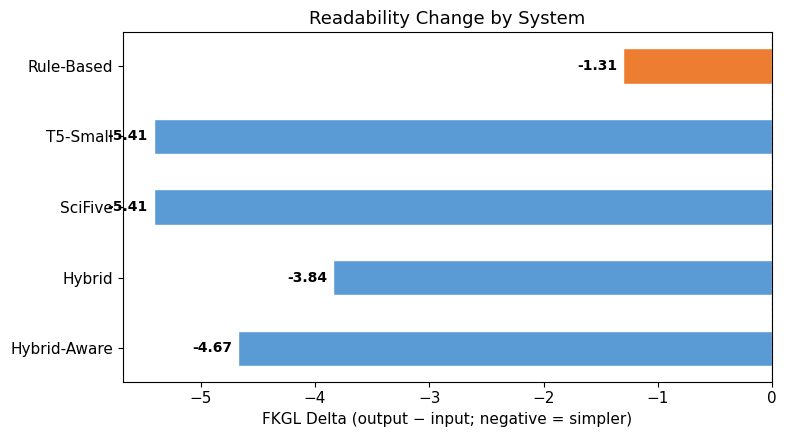

Saved results/figures/fkgl_bar.png


In [7]:
os.makedirs('results/figures', exist_ok=True)

ALL_LABELS = {
    'rule_based':   'Rule-Based',
    't5_small':     'T5-Small',
    'scifive':      'SciFive',
    'hybrid':       'Hybrid',
    'hybrid_aware': 'Hybrid-Aware',
}
systems_ordered = [s for s in DISPLAY_ORDER if s in df['system'].values]
labels          = [ALL_LABELS[s] for s in systems_ordered]

fig, ax = plt.subplots(figsize=(8, max(4, 0.7 * len(systems_ordered) + 1)))
deltas  = [df.loc[df['system'] == s, 'fkgl_delta'].values[0] for s in systems_ordered]
colors  = ['#5B9BD5' if d < -3 else '#ED7D31' for d in deltas]

bars = ax.barh(labels, deltas, color=colors, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, deltas):
    ax.text(val - 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='right', fontsize=10, fontweight='bold')

ax.set_xlabel('FKGL Delta (output − input; negative = simpler)')
ax.set_title('Readability Change by System')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig('results/figures/fkgl_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved results/figures/fkgl_bar.png')

## Section 5 — SARI Bar Chart

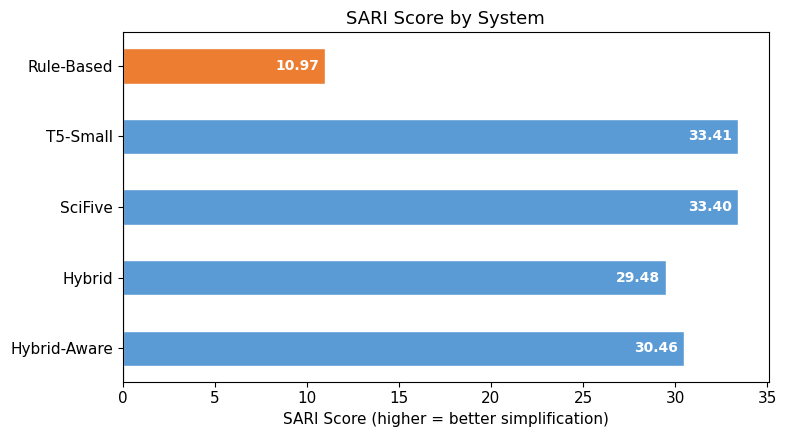

Saved results/figures/sari_bar.png


In [8]:
fig, ax    = plt.subplots(figsize=(8, max(4, 0.7 * len(systems_ordered) + 1)))
saris      = [df.loc[df['system'] == s, 'sari'].values[0] for s in systems_ordered]
colors_sari = ['#5B9BD5' if v > 20 else '#ED7D31' for v in saris]

bars = ax.barh(labels, saris, color=colors_sari, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, saris):
    ax.text(val - 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='right', fontsize=10,
            fontweight='bold', color='white')

ax.set_xlabel('SARI Score (higher = better simplification)')
ax.set_title('SARI Score by System')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig('results/figures/sari_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved results/figures/sari_bar.png')

## Section 6 — Qualitative Example Matrix

In [9]:
IDX = 0
source    = predictions['rule_based'][IDX]['source']
reference = predictions['rule_based'][IDX]['reference']

print('=' * 80)
print('QUALITATIVE EXAMPLE MATRIX')
print('=' * 80)
print(f'SOURCE:      {source}')
print(f'REFERENCE:   {reference}')
print('-' * 80)
for system in systems_ordered:
    label = ALL_LABELS[system]
    if IDX < len(predictions[system]):
        pred = predictions[system][IDX]['prediction']
        print(f'{label:<14}: {pred}')
    else:
        print(f'{label:<14}: (no record at IDX={IDX})')
print('=' * 80)

QUALITATIVE EXAMPLE MATRIX
SOURCE:      The psychosocial interventions considered in the studies were: cognitive-behavioural coping skills training (one study), twelve-step programme (one study), brief intervention (three studies), motivational interviewing (two studies), and brief motivational interviewing (one study).
REFERENCE:   The twelve-step programme is based on theories from Alcoholics Anonymous and aims to motivate the person to develop a desire to stop using drugs or alcohol.
--------------------------------------------------------------------------------
Rule-Based    : The psychosocial interventions considered in the studies were: cognitive-behavioural coping skills training (one study), twelve-step programme (one study), brief intervention (three studies), motivational interviewing (two studies). And brief motivational interviewing (one study).
T5-Small      : The studies included: cognitive-behavioural coping skills training, twelve-step programme, brief intervention, mo

## Section 7 — Error Analysis

In [10]:
def assign_failure_mode(source: str, prediction: str, reference: str) -> str:
    pred_clean = prediction.strip()
    src_clean  = source.strip()
    if pred_clean == src_clean:
        return 'no-change'
    if len(pred_clean.split()) < 0.4 * len(src_clean.split()):
        return 'over-simplification'
    if not pred_clean.endswith(('.', '?', '!')):
        return 'incomplete'
    return 'hallucination'

def find_failure_examples(records, n=2):
    examples = []
    for r in records:
        mode = assign_failure_mode(r['source'], r['prediction'], r['reference'])
        examples.append({**r, 'failure_mode': mode})
        if len(examples) >= n:
            break
    return examples

print('Failure mode heuristics defined.')

Failure mode heuristics defined.


In [11]:
FAILURE_MODES = {'no-change', 'over-simplification', 'incomplete', 'hallucination'}

print('=' * 80)
print('PER-SYSTEM ERROR ANALYSIS (2 examples per system)')
print('=' * 80)

all_failures = {}
for system in systems_ordered:
    label = ALL_LABELS[system]
    examples = find_failure_examples(predictions[system], n=2)
    all_failures[system] = examples
    print(f'\n--- {label} ---')
    for i, ex in enumerate(examples, 1):
        print(f'  [{i}] failure_mode: {ex["failure_mode"]}')
        print(f'      SOURCE:     {ex["source"][:100]}')
        print(f'      PREDICTION: {ex["prediction"][:100]}')
        print(f'      REFERENCE:  {ex["reference"][:100]}')

print('\n' + '=' * 80)

PER-SYSTEM ERROR ANALYSIS (2 examples per system)

--- Rule-Based ---
  [1] failure_mode: hallucination
      SOURCE:     The psychosocial interventions considered in the studies were: cognitive-behavioural coping skills t
      PREDICTION: The psychosocial interventions considered in the studies were: cognitive-behavioural coping skills t
      REFERENCE:  The twelve-step programme is based on theories from Alcoholics Anonymous and aims to motivate the pe
  [2] failure_mode: hallucination
      SOURCE:     We found that there is little to no neutralizing capability following a 2-dose mRNA vaccine series a
      PREDICTION: We found that there is little to no neutralizing capability following a 2-dose mRNA vaccine series a
      REFERENCE:  Healthcare workers were included in the analysis if serum was collected within 14-44 days post-dose 

--- T5-Small ---
  [1] failure_mode: hallucination
      SOURCE:     The psychosocial interventions considered in the studies were: cognitive-behav

## Section 8 — Assertions

In [12]:
df_verify = pd.read_csv('results/metrics.csv')
REQUIRED = {'rule_based', 't5_small', 'scifive', 'hybrid'}
assert REQUIRED.issubset(set(df_verify['system'])), f'missing required systems: {REQUIRED - set(df_verify["system"])}'
assert (df_verify['fkgl_delta'] < 0).all(), 'every system must have fkgl_delta < 0'
assert os.path.exists('results/figures/fkgl_bar.png')
assert os.path.exists('results/figures/sari_bar.png')
for system in SYSTEMS:
    assert len(all_failures[system]) == 2
    for ex in all_failures[system]:
        assert ex['failure_mode'] in FAILURE_MODES

print('ALL ASSERTIONS PASSED')
print(f'  metrics.csv: {len(df_verify)} rows (required: 4, optional: hybrid_aware)')
print(f'  all fkgl_delta < 0')
print(f'  figures: fkgl_bar.png, sari_bar.png')
print(f'  error analysis: {len(SYSTEMS)} systems x 2 failure examples')

ALL ASSERTIONS PASSED
  metrics.csv: 5 rows (required: 4, optional: hybrid_aware)
  all fkgl_delta < 0
  figures: fkgl_bar.png, sari_bar.png
  error analysis: 5 systems x 2 failure examples
